In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [4]:
df = pd.read_csv("urlset.csv", encoding="latin1", on_bad_lines="skip")

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (96005, 14)

First 5 rows:
                                              domain   ranking mld_res  \
0  nobell.it/70ffb52d079109dca5664cce6f317373782/...  10000000     1.0   
1  www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...  10000000     0.0   
2  serviciosbys.com/paypal.cgi.bin.get-into.herf....  10000000     0.0   
3  mail.printakid.com/www.online.americanexpress....  10000000     0.0   
4  thewhiskeydregs.com/wp-content/themes/widescre...  10000000     0.0   

  mld.ps_res  card_rem  ratio_Rrem  ratio_Arem  jaccard_RR  jaccard_RA  \
0        0.0      18.0  107.611111  107.277778         0.0         0.0   
1        0.0      11.0  150.636364  152.272727         0.0         0.0   
2        0.0      14.0   73.500000   72.642857         0.0         0.0   
3        0.0       6.0  562.000000  590.666667         0.0         0.0   
4        0.0       8.0   29.000000   24.125000         0.0         0.0   

   jaccard_AR  jaccard_AA jaccard_ARrd jaccard_ARrem  label  
0     

C:\Users\sanni\AppData\Local\Temp\ipykernel_28576\1992774930.py:1: DtypeWarning: Columns (0: ranking, 1: mld_res, 2: mld.ps_res, 3: jaccard_ARrd, 4: jaccard_ARrem) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("urlset.csv", encoding="latin1", on_bad_lines="skip")


In [5]:
# Remove duplicate records
df = df.drop_duplicates()

# Remove rows with missing labels
df = df.dropna(subset=["label"])

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (95912, 14)


In [6]:
print("\nURL Class Distribution:")
print(df["label"].value_counts())


URL Class Distribution:
label
0.0    48009
1.0    47903
Name: count, dtype: int64


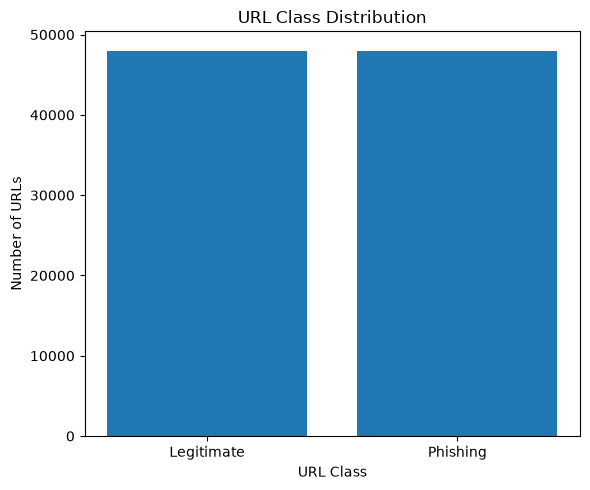

In [7]:
plt.figure(figsize=(6, 5))

class_counts = df["label"].value_counts().sort_index()

plt.bar(
    ["Legitimate", "Phishing"],
    class_counts
)

plt.title("URL Class Distribution")
plt.xlabel("URL Class")
plt.ylabel("Number of URLs")

plt.tight_layout()
plt.show()

In [8]:
# Remove URL column because the model will use extracted features
X = df.drop(columns=["label", "domain"])

# Target
y = df["label"]

print("Number of features:", X.shape[1])

Number of features: 12


In [9]:
X = X.select_dtypes(include=[np.number])

print("Numerical features:", X.shape[1])

Numerical features: 7


In [10]:
X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.median())

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 76729
Testing samples: 19183


In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [13]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("========== MODEL PERFORMANCE ==========")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

========== MODEL PERFORMANCE ==========
Accuracy : 0.7316895167596309
Precision: 0.7846687211093991
Recall   : 0.6378248617054587
F1 Score : 0.7036674535091254


In [15]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.70      0.83      0.75      9602
    Phishing       0.78      0.64      0.70      9581

    accuracy                           0.73     19183
   macro avg       0.74      0.73      0.73     19183
weighted avg       0.74      0.73      0.73     19183



In [16]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[7925 1677]
 [3470 6111]]


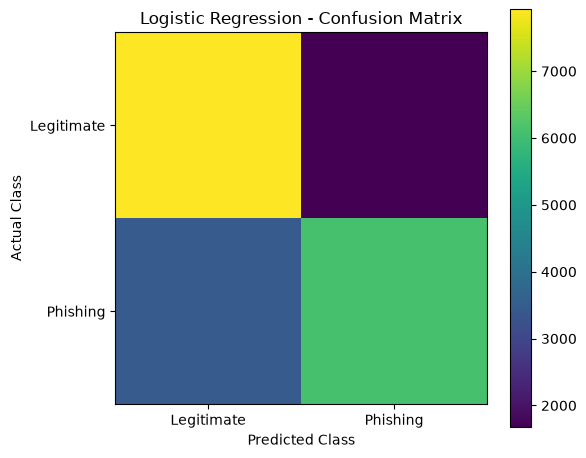

In [17]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Logistic Regression - Confusion Matrix")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Legitimate", "Phishing"]
)

plt.yticks(
    [0, 1],
    ["Legitimate", "Phishing"]
)

plt.colorbar()

plt.tight_layout()
plt.show()

In [18]:
# Get feature coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

# Calculate absolute importance
coefficients["Importance"] = abs(
    coefficients["Coefficient"]
)

# Sort by importance
coefficients = coefficients.sort_values(
    by="Importance",
    ascending=False
)

# Top 15 features
top_features = coefficients.head(15)

print("\nTop 15 Important Features:")
print(top_features)


Top 15 Important Features:
      Feature  Coefficient  Importance
4  jaccard_RA    -4.535983    4.535983
0    card_rem     1.612220    1.612220
5  jaccard_AR     1.460728    1.460728
6  jaccard_AA     1.228733    1.228733
2  ratio_Arem    -1.222117    1.222117
1  ratio_Rrem     1.097220    1.097220
3  jaccard_RR    -0.007987    0.007987


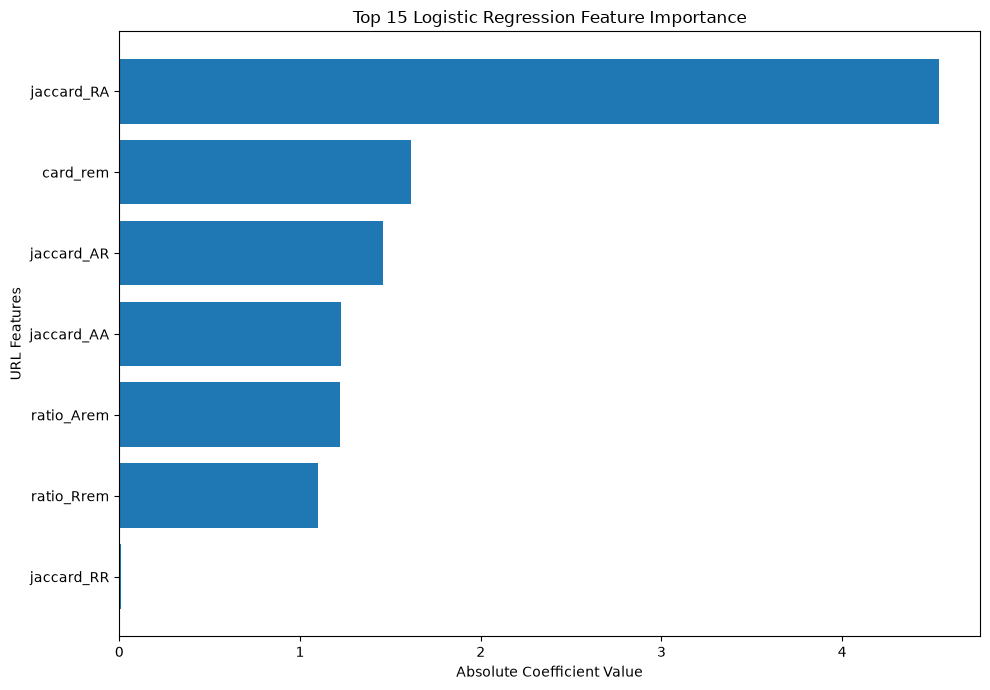

In [19]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title(
    "Top 15 Logistic Regression Feature Importance"
)

plt.xlabel("Absolute Coefficient Value")
plt.ylabel("URL Features")

plt.tight_layout()
plt.show()